# Notebook F of more line ratios from saved maps from the PZ cubes

This is adapted from 01-02-yet-more-line-ratios. It includes the He II analysis


In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
from zz_utils import get_image_raw, ROOT
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## He II emission measure

In [2]:
he2 = pn.RecAtom("He", 2)
he1 = pn.RecAtom("He", 1)
h1 = pn.RecAtom("H", 1)

In [3]:
temperatures = [12500, 13800, 15500]
e4686 = he2.getEmissivity(tem=temperatures, den=1, wave=4686)
e4861 = h1.getEmissivity(tem=temperatures, den=1, wave=4861)
e5875 = he1.getEmissivity(tem=temperatures, den=1, wave=5876)
e4686, e4861, e5875

(array([1.20300000e-24, 1.08441739e-24, 9.59135484e-25]),
 array([1.01400000e-25, 9.26956522e-26, 8.33922581e-26]),
 array([1.31541290e-25, 1.17715862e-25, 1.03205588e-25]))

In [4]:
np.mean(e4861[1])

9.269565217391303e-26

From the other notebook, we measure 5875 / 4861 = 0.108 +/- 0.001

Whereas the ratio of emissivities is

In [5]:
e5875 / e4861

array([1.29725138, 1.26991784, 1.23759196])

This implies a He abundance of

In [6]:
np.array([0.107, 0.108, 0.109])[None, :] / (e5875 / e4861)[:, None]

array([[0.08248209, 0.08325295, 0.08402381],
       [0.08425742, 0.08504487, 0.08583232],
       [0.08645822, 0.08726624, 0.08807426]])

From Table 5 of Valerdi+ (2019), they have a He+ abundance of 10.915 or 10.917, with error of +/- 0.004 , so:

In [7]:
10 ** (np.array([10.915, 10.917]) - 12.0)

array([0.08222426, 0.08260379])

They find a small He++ abundance of

In [8]:
f"He++/H+ = {10 ** (8.30 - 12.0):.3e}; He++/He+ = {10 ** (8.30 - 10.915):.3e}"

'He++/H+ = 1.995e-04; He++/He+ = 2.427e-03'

In the bow shock I measure 4686 / 4861 = 0.015 or so, which would be 1.5 on a scale of Hβ = 100.  Mabel's Table 2 gives 0.24, which is 6 times less. This is consistent with the general value we find away from the bow's inner edge.

So, I can work out my own He++/H+ abundance:

In [9]:
y_heiii_hii = 0.015 / (e4686 / e4861)
y_heiii_heii = y_heiii_hii / 0.08167471
f"Bow shock He++/H+ = {np.round(y_heiii_hii, 4)}; He++/He+ = {np.round(y_heiii_heii, 4)}"

'Bow shock He++/H+ = [0.0013 0.0013 0.0013]; He++/He+ = [0.0155 0.0157 0.016 ]'

In other words, the He++ emission measure, $\int n(\mathrm{He^{++}})\, n_\mathrm{e}\, dz$, is ony 2.5% of the total $\int n(\mathrm{He^{+}})\, n_\mathrm{e}\, dz$.

*This is totally consistent, with the observed small change in 5875/4861, which is also about 2%*

**TODO**

- [ ] By assuming a path length, we can derive a density
- [ ] We can do the same with [Ar IV] and [Ar III]
- [ ] Ask Mabel to look at her slit A to see if she sees the He II and [Ar IV] signatures of the bow shock.  Also, maybe measure [O III] temperature to see if it goes up

### Conversion to a density

We want the surface brightness of He++ in physical units.

MUSE flux units are $10^{-20}\ \mathrm{erg\ s^{-1}\ cm^{-2}\ Å^{-1}\ pix^{-1}}$ in the cube, but we have summed over wavelength pixels, which are 1.4 Å.  The spatial pixels are 0.2 arcsec.

In [10]:
import astropy.units as u

In [11]:
muse_bright_unit = 1e-20 * 1.4 * u.erg / u.s / u.cm**2 / (0.2 * u.arcsec) ** 2
muse_bright_unit.to(u.erg / u.s / u.cm**2 / u.sr)

<Quantity 1.48908096e-08 erg / (s sr cm2)>

In [12]:
datadir = ROOT / "data"
figdir = ROOT / "figs"

In [13]:
im4686 = Image(str(datadir / "ngc346-ZZ-heii-4686-correct.fits"))
im5875 = Image(str(datadir / "ngc346-ZZ-hei-5875-correct.fits"))
imhb = Image(str(datadir / "ngc346-ZZ-hi-4861-correct.fits"))
imariv = Image(str(datadir / "ngc346-ZZ-ariv-4711-plus-4740-correct.fits"))
imariii = Image(str(datadir / "ngc346-ZZ-ariii-7136-correct.fits"))
imoiii = Image(str(datadir / "ngc346-ZZ-oiii-5007-correct.fits"))

Use the same bow shock window as in the E notebook

In [14]:
xslice, yslice = slice(230, 300), slice(144, 245)

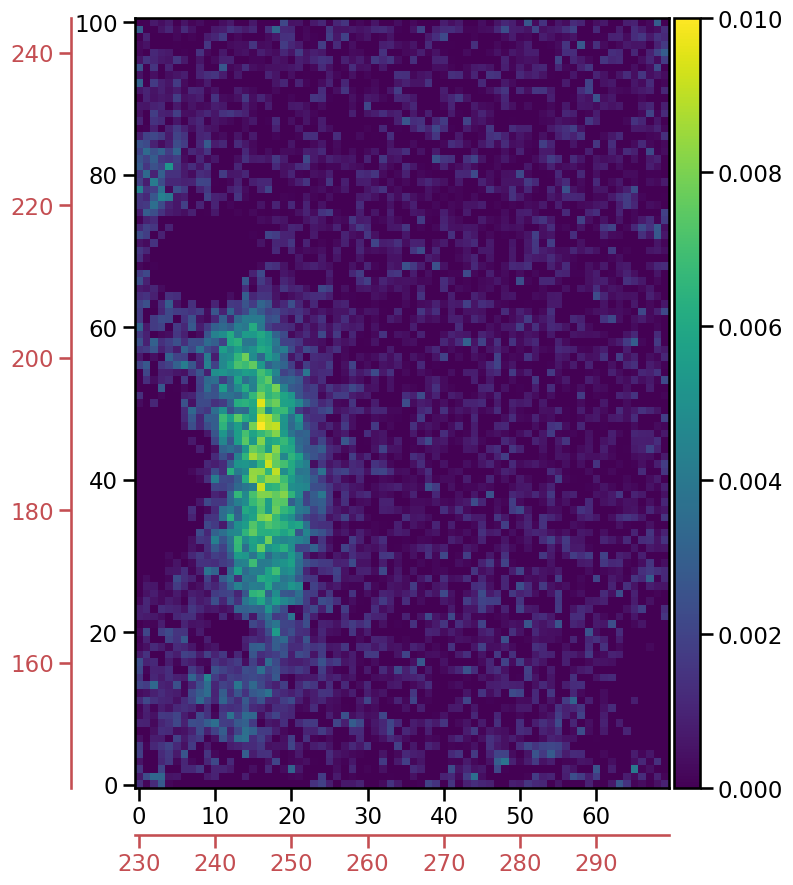

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
(im4686 / imhb)[yslice, xslice].plot(vmin=0.0, vmax=0.01, colorbar="v")
ax_x = ax.secondary_xaxis(
    -0.06, functions=(lambda x: x + xslice.start, lambda x: x - xslice.start), color="r"
)
ax_y = ax.secondary_yaxis(
    -0.12, functions=(lambda y: y + yslice.start, lambda y: y - yslice.start), color="r"
)

In [16]:
xxslice = slice(None, None)
# yyslice = slice(164, 204) # original
# yyslice = slice(160, 210) # broader
# yyslice = slice(170, 200) # narrower
yyslice = slice(180, 200)  # top half ultra narrow


def make_profile(im):
    # return np.make(im[yyslice, xxslice].data, axis=0)
    return np.mean(im[yyslice, xxslice].data, axis=0)


heii_profile = make_profile(im4686)
hei_profile = make_profile(im5875)
hb_profile = make_profile(imhb)
ariv_profile = make_profile(imariv)
ariii_profile = make_profile(imariii)
oiii_profile = make_profile(imoiii)

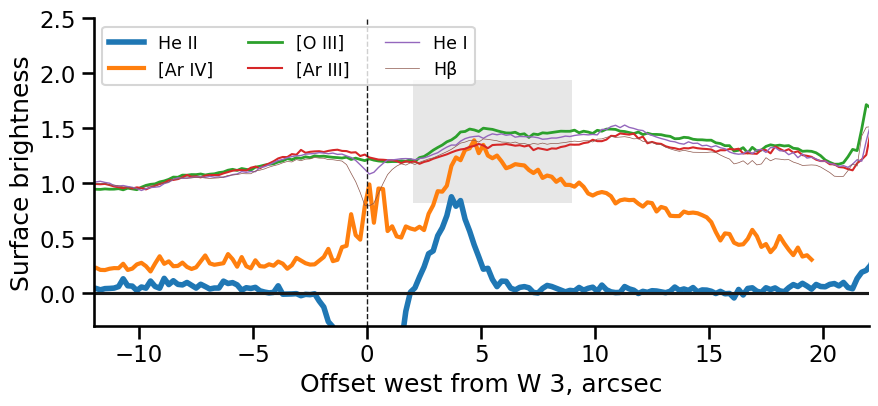

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ix0 = 227.5
nx = len(heii_profile)
pos = (np.arange(nx) - ix0) * 0.2


def _norm(y, x, x1=-12, x2=-7):
    m = (x >= x1) & (x <= x2)
    return y / np.mean(y[m])


ax.plot(pos, _norm(heii_profile, pos, x1=2, x2=5) / 2, label="He II", lw=4)
ax.plot(pos, _norm(ariv_profile, pos) / 4, label="[Ar IV]", lw=3)
fac = 3 * 0.0014
ax.plot(pos, _norm(oiii_profile, pos), label="[O III]", lw=2.0)
fac = 3 * 0.145
ax.plot(pos, _norm(ariii_profile, pos), label="[Ar III]", lw=1.5)
fac = 3 * 0.100
ax.plot(pos, _norm(hei_profile, pos), label="He I", lw=1.0)
fac = 3 * 0.0105
ax.plot(pos, _norm(hb_profile, pos), label="Hβ", lw=0.5)


ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=3, loc="upper left", fontsize="x-small")

ax.set(
    xlabel="Offset west from W 3, arcsec",
    ylabel="Surface brightness",
    xlim=[-12, 22],
    ylim=[-0.3, 2.5],
)
sns.despine()
fig.savefig(figdir / "ngc346-ZZ-bow-shock-brightness-cuts.pdf")

From the profile graph above, the peak He II brightness is about 400 MUSE brightness units

In [18]:
peak_heii_muse = np.max(heii_profile[(pos > 0) & (pos < 10)])
peak_heii_muse

399.3841857910156

In [19]:
peak_heii = muse_bright_unit * peak_heii_muse
peak_heii

<Quantity 1.39784465e-16 erg / (s arcsec2 cm2)>

In [20]:
mshell = (abs(pos) < 10) & (heii_profile > 100)
heii_profile[mshell]

masked_array(data=[108.4756329536438, 163.22602615356445,
                   175.01604347229005, 237.70564651489258,
                   270.88983154296875, 320.960863494873,
                   399.3841857910156, 360.2578063964844,
                   383.69867477416994, 306.2482486724854,
                   257.03363304138185, 199.76339988708497,
                   150.2915382385254, 102.65041160583496],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False],
       fill_value=1e+20)

In [21]:
pos[mshell]

array([2.5, 2.7, 2.9, 3.1, 3.3, 3.5, 3.7, 3.9, 4.1, 4.3, 4.5, 4.7, 4.9,
       5.3])

From the image, the chord length through the bow is about 60 pixels.  We can assume that the line-of-sight depth is similar:

In [22]:
depth_heii = 60 * 0.2 * 61700 * u.au
depth_heii.to(u.pc)

<Quantity 3.58956049 pc>

Surface brightness assuming optically thin emission with isotropic line emissivity, $e(\lambda)$, is given by
$$
I(\lambda) = \int \frac{e(\lambda)\, n_e\, n_i}{4 \pi} \, dz
$$
where $e(\lambda)$ is in the units given by pyneb: `u.erg * u.cm**3 / u.s` and $n_e$, $n_i$ are the electron and ion densities.

Assume neutral fractions of He and H are negligible and hydrogen number density is $n$.  If the He abundance is $y = n(\mathrm{He}) / n(\mathrm{H})$ and the He++ ion fraction is $x_{++}$, then we have:
$$
n(\mathrm{He^{++}}) = y\, x_{++}\, n \quad \text{and} \quad n_e = [1 + y\, (1 + x_{++})]\, n
$$
implying that
$$
n(\mathrm{He^{++}}) \, n_e = n_e^2 \, \frac{y\, x_{++}}{1 + y\, (1 + x_{++})}
$$

So, with homogeneous conditions, we have
$$
I(4686) =
\frac{e(4686)}{4\pi}\,
\frac{y\, x_{++}}{1 + (1 + x_{++}) y}
\, n_e^2 \, \delta z
$$
which can be solved for density to yield
$$
n_e = \left[
\frac{4\pi\, I(4686)}{\delta z\, e(4686)} \, \frac{1 + (1 + x_{++}) y}{x_{++}\,y}
\right]^{1/2}
$$

We can take the helium abundance from above and get ...

In [23]:
pn_e_units = u.erg * u.cm**3 / u.s
yHe = 0.0824
ne = np.sqrt(
    4
    * np.pi
    * u.sr
    * peak_heii
    / (depth_heii.cgs * e4686 * pn_e_units)
    * (1 + 2 * yHe)
    / yHe
).to(u.cm**-3)
ne

<Quantity [8.90415825, 9.37837181, 9.97207886] 1 / cm3>

**So electron density of 11 pcc!**

Note, however that this assumes that the helium is 100% doubly ionized in the 4686 emitting region. If it is only partially ionized, then this is a lower limit (density would scale approximately as $x_{++}^{-1/2}$).

The He II / Hb ratio is so low that the the ion fraction must be small.

#### Find the He II flux and the He++ ionizing luminosity



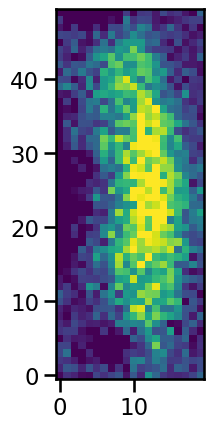

In [24]:
im4686[160:210, 235:255].plot(vmin=0, vmax=400)

In [25]:
muse_flux_unit = 1e-20 * 1.4 * u.erg / u.s / u.cm**2

Calculate the intrinsic flux of the He II line, taking into account the foreground extinction (calculated from the Balmer decrement in the previous notebook)

In [26]:
cutout = im4686[160:210, 235:255]
m = (cutout.data > 0.0) & ~cutout.mask
A_heii = 0.34
F_heii = muse_flux_unit * np.sum(cutout.data[m]) * 10 ** (0.4 * A_heii)
F_heii

<Quantity 2.80390915e-15 erg / (s cm2)>

In [27]:
D_lmc = 61700 * u.pc

In [28]:
L_heii = 4 * np.pi * D_lmc.cgs**2 * F_heii
L_heii

<Quantity 1.27715974e+33 erg / s>

In [29]:
L_heii.to(u.solLum)

<Quantity 0.3336363 solLum>

Effective recomb rate:

In [30]:
import astropy.constants as constants

In [31]:
hnu4686 = (constants.h * constants.c / (4686 * u.Angstrom)).cgs
hnu4686

<Quantity 4.23910768e-12 erg>

In [32]:
alpha_eff_4686 = e4686 * pn_e_units / hnu4686
alpha_eff_4686

<Quantity [2.83786139e-13, 2.55812655e-13, 2.26258816e-13] cm3 / s>

In [33]:
pn.atomicData.getAllAvailableFiles("He2")

['* 3he_ii_atom_cloudy.dat',
 '* 3he_ii_coll_cloudy.dat',
 '* he_ii_rec_SH95.hdf5',
 'he_ii_rec_P91.func',
 'he_ii_rec_SH95-caseA.fits',
 'he_ii_rec_SH95-caseA.hdf5',
 'he_ii_rec_SH95.fits',
 'he_ii_trc_SH95-caseA.dat',
 'he_ii_trc_SH95-caseB.dat']

It only works as follows:

In [34]:
pn.atomicData.setDataFile("he_ii_trc_SH95-caseB.dat")
alphaB_He_plus = pn.RecAtom("He", 2).getTotRecombination(tem=temperatures, den=100)
alphaB_He_plus *= u.cm**3 / u.s
alphaB_He_plus

<Quantity [1.29700000e-12, 1.20528923e-12, 1.10235464e-12] cm3 / s>

Solid angle:

Originally, I had assumed a +
/- 75 degree end cap. But after doing some estimates in the org file, I find that 54 +/- 16 deg is a better estimate

In [35]:
Omega_over_4pi = (1 - np.cos(54 * u.deg)) / 2
Omega_over_4pi

<Quantity 0.20610737>

$$
Q \frac{\Omega}{4\pi} = \int_{\mathcal{V}} n_e \, n_i \, \alpha_B\, d\mathcal{V}
$$
and
$$
L(4686) = \int_{\mathcal{V}} n_e \, n_i \, e(4686)\, d\mathcal{V}
$$
so that
$$
Q = \frac{\alpha_B \, L(4686)} {e(4686)\, (\Omega/4\pi)}
$$

In [36]:
Q2 = alphaB_He_plus * L_heii / (e4686 * pn_e_units) / Omega_over_4pi
Q2

<Quantity [6.68076260e+45, 6.88726020e+45, 7.12185401e+45] 1 / s>

This is way higher than what we got last time, which is due to including the effects of foreground extinction plus a smaller esitimate of the covering fraction. The uncertainty is +/- 50%, which is dominated by the uncertainty in the covering fraction.

## Alternative route to density from Balmer lines

We can estimate the bow shock shell emission measure from the jump in the surface brightness of H beta, say. This has the advantage that we know that the hydrogen is fully ionized.

7344.481369977671

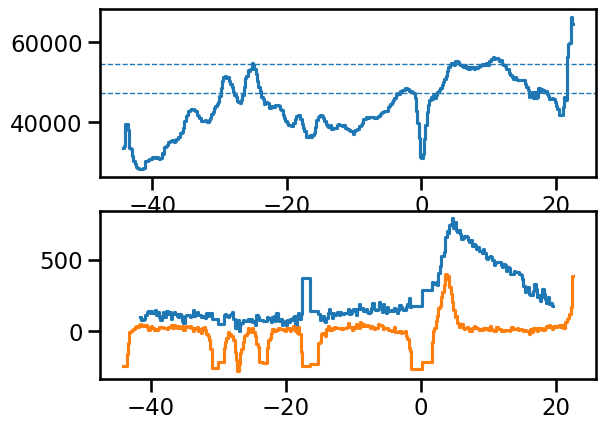

In [64]:
fig, (ax1, ax2) = plt.subplots(2, 1)
m = heii_profile > -300
ax1.plot(pos, hb_profile, ds="steps-mid")
ax2.plot(pos[m], ariv_profile[m], ds="steps-mid")
ax2.plot(pos[m], heii_profile[m], ds="steps-mid")
mm = m & (np.abs(pos) <= 2)
base = np.mean(hb_profile[mm])
ax1.axhline(base, lw=1, ls="dashed")
mmm = m & (pos >= 4) & (pos <= 6)
plateau = np.mean(hb_profile[mmm])
ax1.axhline(plateau, lw=1, ls="dashed")
(plateau - base)

In [65]:
A_hb = 0.33
jump_hb = (plateau - base) * muse_bright_unit * 10 ** (0.4 * A_hb)
f"{jump_hb=}"

'jump_hb=<Quantity 3.48360719e-15 erg / (s arcsec2 cm2)>'

This uses my estimate of the jumpfrom the above profile graph. It is a bit tricky, since we need to take into account the photospheric absorption line.

Thhen we also correct for the dust extinction `A_hb`.

So this should be the intrinsic surface brightness of Hb, which should be EM times emission coefficient / 4 pi


In [66]:
EM = jump_hb * (4 * np.pi * u.sr).to(u.arcsec**2) / (e4861 * pn_e_units)
EM

<Quantity [1.83675552e+22, 2.00923134e+22, 2.23338490e+22] 1 / cm5>

There are three answers, corrending to assumed temperature of 12,500, 13,800, or 15,500 K

In [67]:
np.sqrt(EM / depth_heii).to(u.cm**-3)

<Quantity [40.72206245, 42.59112002, 44.90408758] 1 / cm3>

So that gives a bigger density than I was getting before. On the other hand, it might be a slight over-estimate since the H+ path length may be larger by a factor of 2 (see next section). There is also a small correction for the ionized helium contribution to the electron density, but that is much smaller than the uncertainty in the path length.

So, we would finally get


In [68]:
np.sqrt(EM / (2 * depth_heii)).to(u.cm**-3)

<Quantity [28.7948465 , 30.11646979, 31.75198483] 1 / cm3>

So, taking into account the uncertainty in the path length would give us a hydrogen density of 35 +/- 10 pcc

### Sanity check from He II / H I

In principle, we can come to the same conclusion starting from the 4686/4861 ratio, so long as we account for the fraction of the H beta emission that comes from the bow shock.

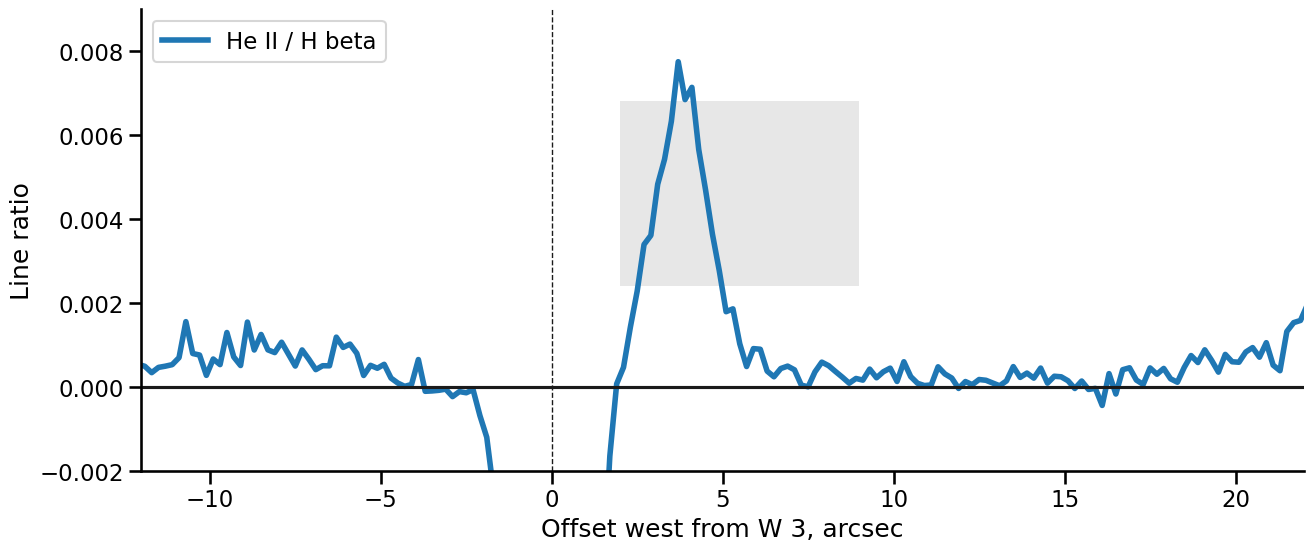

In [77]:
fig, ax = plt.subplots(figsize=(15, 6))
ix0 = 227.5
nx = len(heii_profile)
pos = (np.arange(nx) - ix0) * 0.2
imargin = 10
ratio = heii_profile / hb_profile
ax.plot(pos[imargin:], ratio[imargin:], label="He II / H beta", lw=4)

ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=3, loc="upper left")

ax.set(
    xlabel="Offset west from W 3, arcsec",
    ylabel="Line ratio",
    xlim=[-12, 22],
    ylim=[-0.002, 0.009],
    # ylim = [-0.1, 0.5],
)
sns.despine()
fig.savefig(figdir / "ngc346-bow-shock-heii-hbeta-cuts.pdf")

So the peak ratio is about 0.015. Note that we already did this once above in the *He II emission measure* section. We got exactly the same value.

We now have to divide this by the fraction of H beta that comes frm the bow shock.

In [78]:
hb_bow_frac = (plateau - base) / base
hb_bow_frac

0.15553913546111267

In [79]:
heii_hb_bow_max = np.max(ratio[imargin:]) / hb_bow_frac
heii_hb_bow_max

0.04981128550295954

Then we should have
$$
\texttt{heii\_hb\_bow\_max} =
\frac{I(4686)}{I(4681)} =
\frac{
\int e(4686)\, n(\mathrm{He^{++}})\, n_e\, dz
}{
\int e(4861)\, n(\mathrm{H^+})\, n_e\, dz
}
\approx
\frac{e(4686)}{e(4861)}\,
y(\mathrm{He})\,
x(\mathrm{He}^{++})
$$

In [80]:
e4686, e4861, e4686 / e4861

(array([1.20300000e-24, 1.08441739e-24, 9.59135484e-25]),
 array([1.01400000e-25, 9.26956522e-26, 8.33922581e-26]),
 array([11.86390533, 11.69868668, 11.50149314]))

So the He II emission coefficient is about 12 times larger than H beta, which almost exactly cancels out the He abundance factor. And the temperature dependence is very slight.

In [81]:
yhe = 0.08325295
xheiii = (heii_hb_bow_max * e4861) / (yhe * e4686)
xheiii

array([0.05043133, 0.05114357, 0.05202042])

Note that this assumes that the line-of-sight path length is the same for He++ and for H+. In reality it may be longer for H+ because the thickness of the emitting shell is greater. In the thin shell approximation, the ratio of path lengths is the sqrt of the ratio of thickness.

The ratio of thicknesses is between 2 and 5, depending on just how we measure it. So this would give a ratio of path lengths of about (2 +/- 1), which is also what you would have guessed by looking at the chord lengths on the plane of the sky (for [Ar IV] and He II).

This would give a final value of $x(\mathrm{He^{++}}) \approx 0.1$

Note that this is the same answer as I got from the ESO cube

We can combine this with the derived ionizing luminosity to get another measure of the density, although I am not sure this is actually independent of the other measures